# 반도체 공정 스케줄링 시뮬레이션 결과 비교

## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from itertools import product
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

load_dotenv(override=True)

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
# Machine 모듈은 os.getenv로 매번 읽으므로 변수만으로는 부족 -> 환경변수에도 명시 반영.
os.environ['PM_ACTIVE'] = 'True' if PM_ACTIVE else 'False'
os.environ['DOWN_ACTIVE'] = 'True' if DOWN_ACTIVE else 'False'


BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.1
PM_ACTIVE: False
DOWN_ACTIVE: True


## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler


## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 60 개 / Operations: 840 개 / Machines: 60 개


## COMPOSITE 파라미터 설정

`JOB_RULES`에 `COMPOSITE`가 포함된 경우 아래 값이 사용된다.
`tuning/grid_search.ipynb`의 grid search / Bayesian Optimization으로 얻은 최적값을 직접 입력한다.

- `COMPOSITE_ALPHA_TERM`: α 항의 정의를 토글 (`'WAIT_TIME'` 또는 `'CRITICAL_RATIO'`)
- `α (alpha)`: α-term 가중치 (대기시간 또는 critical ratio)
- `β (beta)`: slack_qtime 가중치 — qtime 위험도(작을수록 우선)
- `γ (gamma)`: c_transition 가중치 — 다음 transition의 위험도. **`tuning/transition_risk.json`** 로딩 필수 (없으면 항이 0배가 되어 무력화)
- `δ (delta)`: setup time 가중치</cell>

In [4]:
import json
from simulation.priority import set_transition_risk_table

# === α-term 선택 (grid_search 채택 후보에 맞춤) ===
COMPOSITE_ALPHA_TERM = 'WAIT_TIME'   # 'WAIT_TIME' | 'CRITICAL_RATIO'
os.environ['COMPOSITE_ALPHA_TERM'] = COMPOSITE_ALPHA_TERM

# === COMPOSITE 가중치 직접 입력 (tuning/grid_search.ipynb의 best_w / BO 결과) ===
COMPOSITE_ALPHA = 0.2
COMPOSITE_BETA  = 0.4
COMPOSITE_GAMMA = 0.2
COMPOSITE_DELTA = 0.2
os.environ['COMPOSITE_ALPHA'] = str(COMPOSITE_ALPHA)
os.environ['COMPOSITE_BETA']  = str(COMPOSITE_BETA)
os.environ['COMPOSITE_GAMMA'] = str(COMPOSITE_GAMMA)
os.environ['COMPOSITE_DELTA'] = str(COMPOSITE_DELTA)

# === transition 위험 테이블 로드 (saa_evaluator가 캐시한 값) ===
# 이 파일이 없으면 c_transition 항이 0으로 동작 → γ 가중치 무력화됨.
RISK_CACHE = os.path.join('tuning', 'transition_risk.json')
if os.path.exists(RISK_CACHE):
    with open(RISK_CACHE, 'r', encoding='utf-8') as f:
        _risk_table = json.load(f)
    set_transition_risk_table(_risk_table)
    print(f"transition risk table loaded: {_risk_table}")
else:
    print(f"[WARN] {RISK_CACHE} not found → c_transition 항이 0으로 동작 (γ 무력)")

print(f"\nα-term = {COMPOSITE_ALPHA_TERM}")
print(f"w = (a={COMPOSITE_ALPHA}, b={COMPOSITE_BETA}, g={COMPOSITE_GAMMA}, d={COMPOSITE_DELTA})")

transition risk table loaded: {'G1->G3': 0.38716858000273935, 'G1->G4': 1.0}

α-term = WAIT_TIME
w = (a=0.2, b=0.4, g=0.2, d=0.2)


## 룰 비교 함수 정의

In [5]:
def run_simulation(job_rule, pm_rule):
    env = simpy.Environment()
    logger = EventLogger(env)

    os.environ['JOB_RULE'] = job_rule
    os.environ['PM_RULE'] = pm_rule
    scheduler = Scheduler(
        env=env,
        data=data,
        event_logger=logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD)
    )
    env.run(until=scheduler.job_chk_process)
    return logger.logs

## 룰별 N회 시뮬레이션 평균 비교

In [6]:
N_RUNS = 30
JOB_RULES = [
    'random',
    'FIFO',
    'SPT',
    'LPT',
    'MIN_QTIME',
    'SPTSSU',
    'COMPOSITE'
]
PM_RULES = [
    'THRESHOLD'
]

# transition 메타 사전 계산
op_meta = data['operations'][['job_id', 'op_id', 'op_seq', 'op_group']].copy()
prev_op_meta = op_meta.copy()
prev_op_meta['op_seq'] = prev_op_meta['op_seq'] + 1
prev_op_meta = prev_op_meta.rename(columns={'op_group': 'prev_op_group'})[['job_id', 'op_seq', 'prev_op_group']]
op_with_prev = op_meta.merge(prev_op_meta, on=['job_id', 'op_seq'], how='left')
op_with_prev['transition'] = op_with_prev['prev_op_group'] + '-' + op_with_prev['op_group']
job_type_map = data['jobs'].set_index('job_id')['job_type']

metrics = []
seed = time.time()
for (job_rule, pm_rule, idx) in product(JOB_RULES, PM_RULES, range(N_RUNS)):
    random.seed(hash((seed, idx)))
    logs = run_simulation(job_rule, pm_rule)
    log = pd.DataFrame(logs)
    job_log = log[log['resource'] == 'job']
    machine_log = log[log['resource'] == 'machine']

    makespan = job_log.groupby('id')['finish'].max().max()
    flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
    flowtime = flowtime.to_frame(name='flowtime').join(job_type_map, on='id')
    flowtime = flowtime.groupby('job_type')['flowtime'].mean()

    completed = job_log.groupby('id')['finish'].max()
    job_duetime_map = data['jobs'].set_index('job_id')['due_date']
    tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
    tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
    tardiness = tardiness.join(job_type_map, on='id')
    tardiness = tardiness.groupby('job_type')['tardiness'].mean()

    qtime_violations = job_log[job_log['event'] == 'qtime_over']
    qtime_total = sum(qtime_violations['finish'] - qtime_violations['start'])

    # transition별 위반 시간 집계
    qv = qtime_violations.copy()
    qv['violation'] = qv['finish'] - qv['start']
    qv = qv.merge(op_with_prev[['op_id', 'transition']], on='op_id', how='left')
    qv = qv.rename(columns={'id': 'job_id'}).join(job_type_map, on='job_id')
    transition_violation = qv.groupby(['job_type', 'transition'])['violation'].sum()

    n_pm = len(machine_log[machine_log['event'] == 'PM'])
    n_repairs = len(machine_log[machine_log['event'] == 'repairing'])

    utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (x['finish'] - x['start']).sum() / makespan)
    machine_group_map = data['machines'].set_index('machine_id')['machine_group']
    utilization = utilization.to_frame(name='utilization').join(machine_group_map, on='id')
    utilization = utilization.groupby('machine_group')['utilization'].mean()

    metrics.append({
        'job_rule': job_rule,
        'pm_rule': pm_rule,
        'try': idx + 1,
        'makespan': makespan,
        'flowtime': flowtime,
        'tardiness': tardiness,
        'qtime_violations': qtime_total,
        'transition_violation': transition_violation,
        'n_pm': n_pm,
        'n_repairs': n_repairs,
        'utilization': utilization
    })
metrics_df = pd.DataFrame(metrics)

C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\1942566072.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flowtime = job_log.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\1942566072.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  utilization = machine_log[machine_log['event'].str.startswith('working')].groupby('id').apply(lambda x: (

## Makespan

C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\1458178020.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)


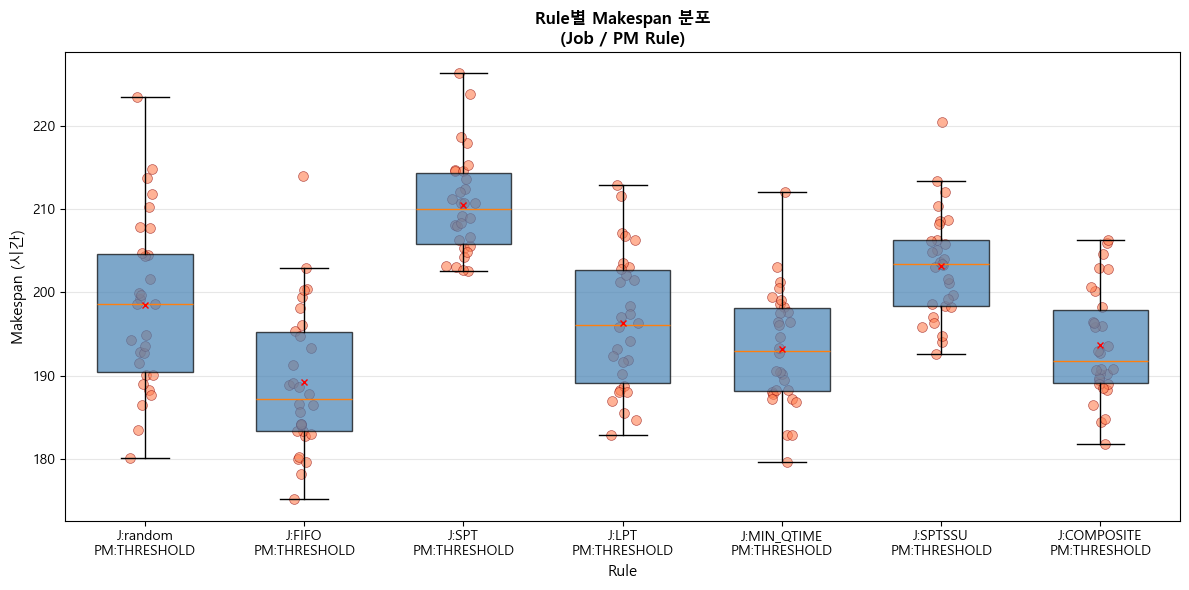

In [7]:
_unit_label = {'M': '분', 'H': '시간', 'D': '일'}.get(os.getenv('TIME_UNIT', 'M'), '분')
fig, ax = plt.subplots(figsize=(12, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

box_data = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['makespan'].values for idx in rule_indices]

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel(f'Makespan ({_unit_label})', fontsize=11)
ax.set_title('Rule별 Makespan 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Qtime Violation

C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\3200341969.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)


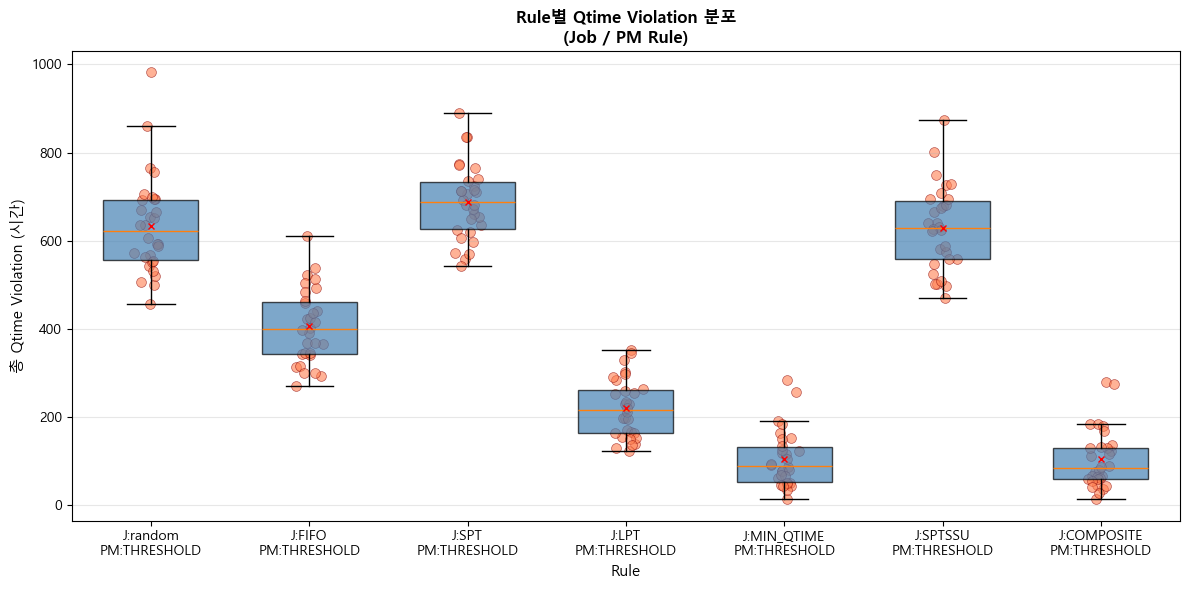

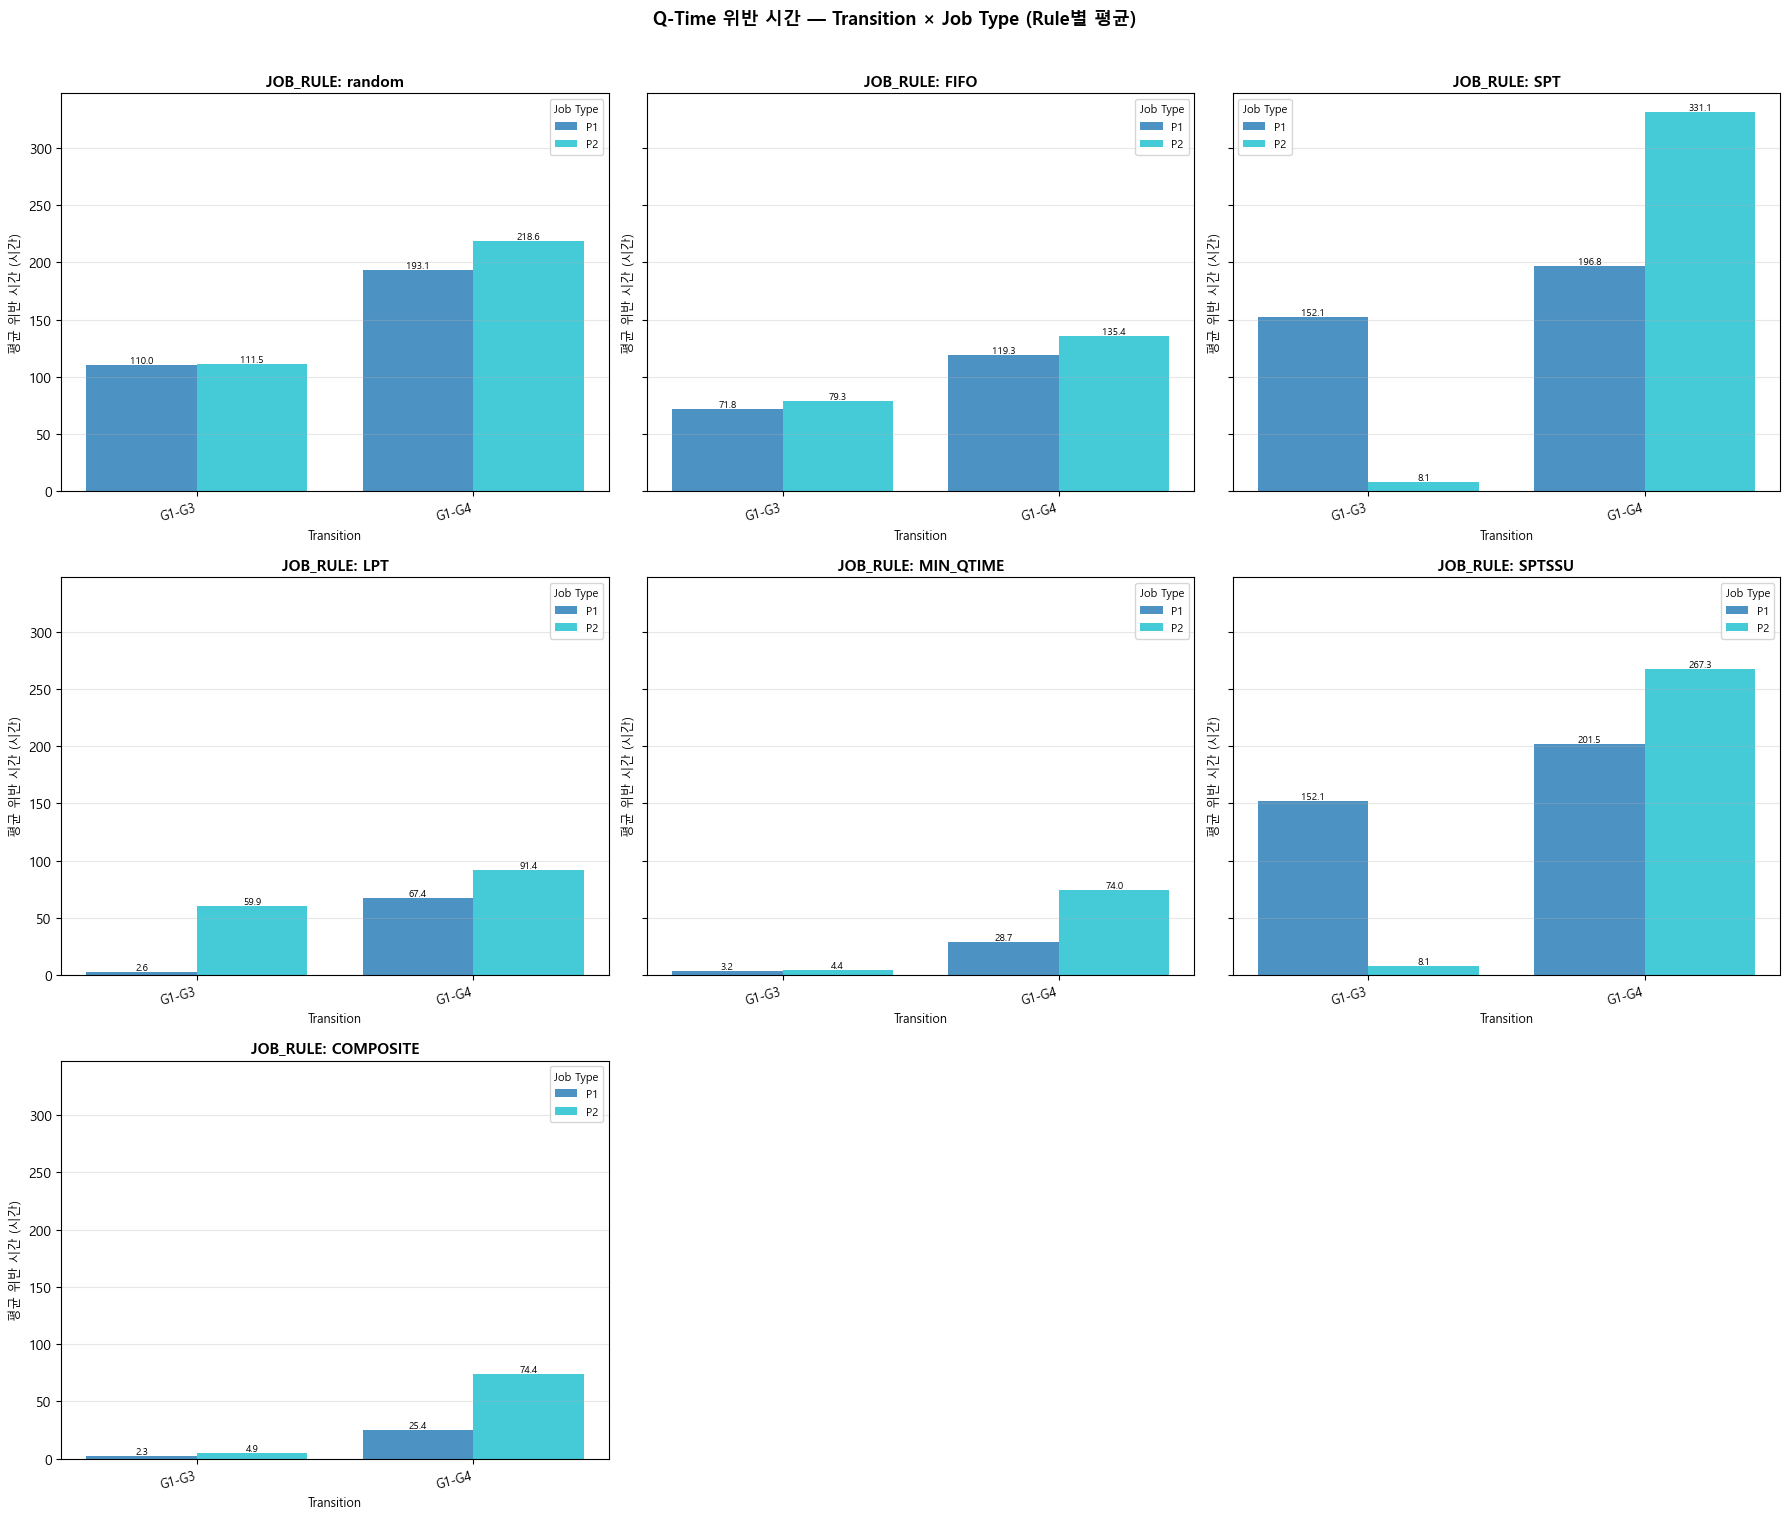

In [8]:
# ── 그래프 1: Rule별 Qtime Violation 분포 (boxplot) ──────────────────────────
_unit_label = {'M': '분', 'H': '시간', 'D': '일'}.get(os.getenv('TIME_UNIT', 'M'), '분')

fig, ax = plt.subplots(figsize=(12, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

box_data = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['qtime_violations'].values for idx in rule_indices]

bp = ax.boxplot(box_data, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

for i, data in enumerate(box_data):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    ax.scatter(x_jittered, data, alpha=0.6, s=50, color='coral', edgecolors='darkred', linewidth=0.5)
    ax.plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='red', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel(f'총 Qtime Violation ({_unit_label})', fontsize=11)
ax.set_title('Rule별 Qtime Violation 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 그래프 2: Qtime Violation — Transition × Job Type (rule별 서브플롯) ────────
# 전체 run의 transition_violation을 합산하여 long-form DataFrame 생성
tv_rows = []
for _, row in metrics_df.iterrows():
    if isinstance(row['transition_violation'], pd.Series) and len(row['transition_violation']) > 0:
        for (job_type, transition), val in row['transition_violation'].items():
            tv_rows.append({
                'job_rule': row['job_rule'],
                'pm_rule': row['pm_rule'],
                'job_type': job_type,
                'transition': transition,
                'violation': val
            })

tv_df = pd.DataFrame(tv_rows)

if len(tv_df) > 0:
    all_transitions = sorted(tv_df['transition'].unique())
    all_job_types = sorted(tv_df['job_type'].unique())
    n_rules = len(JOB_RULES)
    n_cols = 3
    n_rows = (n_rules + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_job_types), 1)))
    bar_width = 0.8 / max(len(all_job_types), 1)
    x = np.arange(len(all_transitions))

    for rule_idx, job_rule in enumerate(JOB_RULES):
        ax = axes[rule_idx]
        rule_df = tv_df[tv_df['job_rule'] == job_rule]

        pivot = rule_df.groupby(['transition', 'job_type'])['violation'].mean().unstack('job_type').reindex(
            index=all_transitions, columns=all_job_types, fill_value=0
        )

        for jt_idx, job_type in enumerate(all_job_types):
            offset = (jt_idx - (len(all_job_types) - 1) / 2) * bar_width
            vals = pivot[job_type].values if job_type in pivot.columns else np.zeros(len(all_transitions))
            bars = ax.bar(x + offset, vals, bar_width, label=job_type, color=colors[jt_idx], alpha=0.8)
            for bar in bars:
                h = bar.get_height()
                if h > 0.5:
                    ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}',
                            ha='center', va='bottom', fontsize=7)

        ax.set_title(f'JOB_RULE: {job_rule}', fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(all_transitions, rotation=15, ha='right', fontsize=9)
        ax.set_xlabel('Transition', fontsize=9)
        ax.set_ylabel(f'평균 위반 시간 ({_unit_label})', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(title='Job Type', fontsize=8, title_fontsize=8)

    # 빈 서브플롯 숨기기
    for i in range(n_rules, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('Q-Time 위반 시간 — Transition × Job Type (Rule별 평균)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Q-Time 위반 데이터가 없습니다.")

## PM & Repair

C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\1026017611.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_pm = axes[0].boxplot(box_data_pm, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)
C:\Users\hun99\AppData\Local\Temp\ipykernel_30596\1026017611.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_repair = axes[1].boxplot(box_data_repair, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)


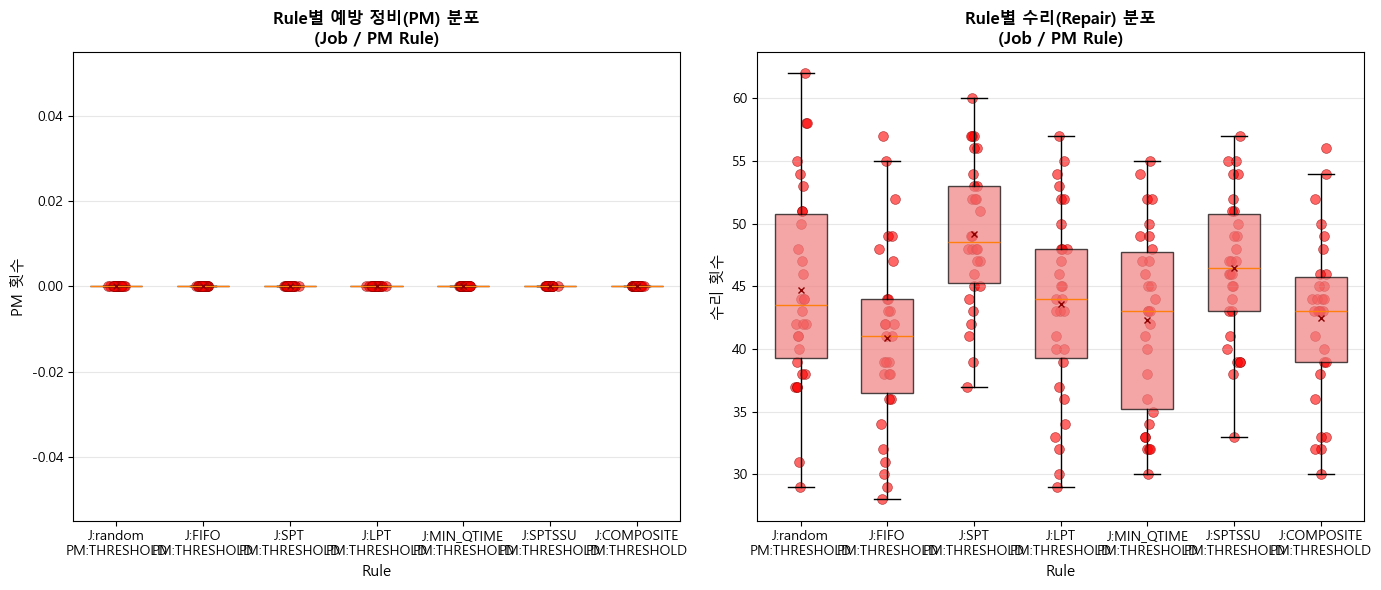

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

# PM 비교
box_data_pm = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['n_pm'].values for idx in rule_indices]

bp_pm = axes[0].boxplot(box_data_pm, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch in bp_pm['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)

for i, data in enumerate(box_data_pm):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    axes[0].scatter(x_jittered, data, alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5)
    axes[0].plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='darkred', zorder=3)

axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('PM 횟수', fontsize=11)
axes[0].set_title('Rule별 예방 정비(PM) 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Repair 비교
box_data_repair = [metrics_df[
    (metrics_df['job_rule'] == idx[0]) &
    (metrics_df['pm_rule'] == idx[1])
]['n_repairs'].values for idx in rule_indices]

bp_repair = axes[1].boxplot(box_data_repair, labels=rule_labels, patch_artist=True, widths=0.6, showfliers=False)

for patch in bp_repair['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)

for i, data in enumerate(box_data_repair):
    x_pos = [i + 1] * len(data)
    x_jittered = [x + np.random.normal(0, 0.04) for x in x_pos]
    axes[1].scatter(x_jittered, data, alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5)
    axes[1].plot(i + 1, np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='darkred', zorder=3)

axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('수리 횟수', fontsize=11)
axes[1].set_title('Rule별 수리(Repair) 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Utilization

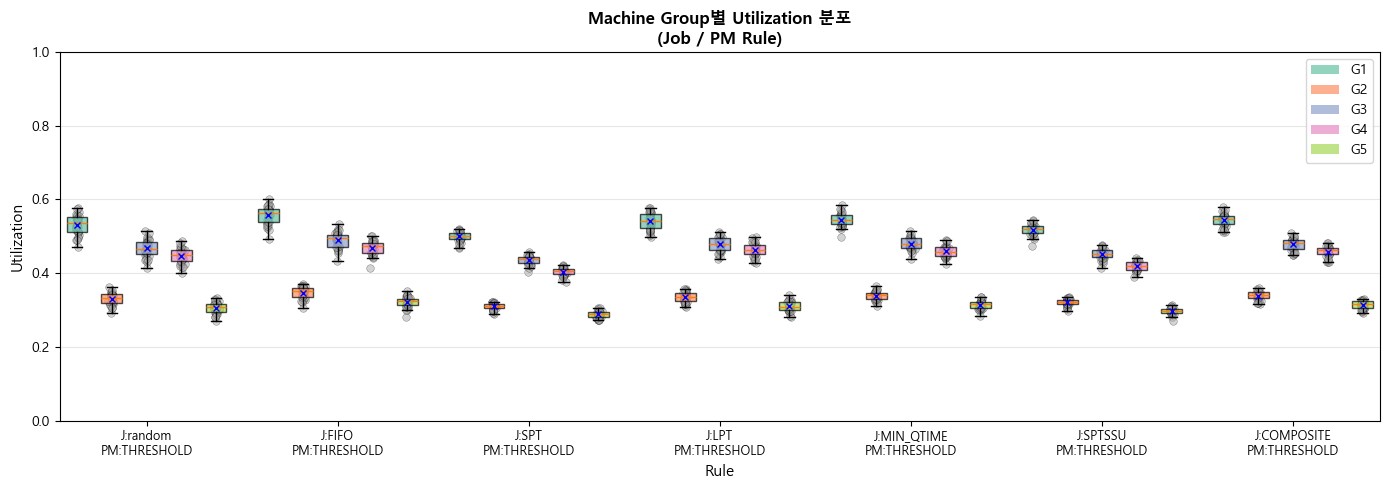

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

utilization_data = []
for idx, row in metrics_df.iterrows():
    for machine_group, util_val in row['utilization'].items():
        utilization_data.append({
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'machine_group': machine_group,
            'utilization': util_val
        })

utilization_df = pd.DataFrame(utilization_data)

machine_groups = sorted(utilization_df['machine_group'].unique())
rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

for mg_idx, machine_group in enumerate(machine_groups):
    box_data = []
    for rule_idx in rule_indices:
        data = utilization_df[
            (utilization_df['job_rule'] == rule_idx[0]) &
            (utilization_df['pm_rule'] == rule_idx[1]) &
            (utilization_df['machine_group'] == machine_group)
        ]['utilization'].values
        box_data.append(data if len(data) > 0 else [0])
    
    positions = np.arange(len(rule_indices)) * (len(machine_groups) + 0.5) + mg_idx
    bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                    showfliers=False)
    
    colors = plt.cm.Set2(range(len(machine_groups)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[mg_idx])
        patch.set_alpha(0.7)
    
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            ax.scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            ax.plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=3)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('Utilization', fontsize=11)
ax.set_title('Machine Group별 Utilization 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
ax.set_xticks(np.arange(len(rule_indices)) * (len(machine_groups) + 0.5) + (len(machine_groups) - 1) / 2)
ax.set_xticklabels(rule_labels, fontsize=9)
ax.legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set2(i), alpha=0.7) for i in range(len(machine_groups))],
          machine_groups, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Flowtime & Tardiness

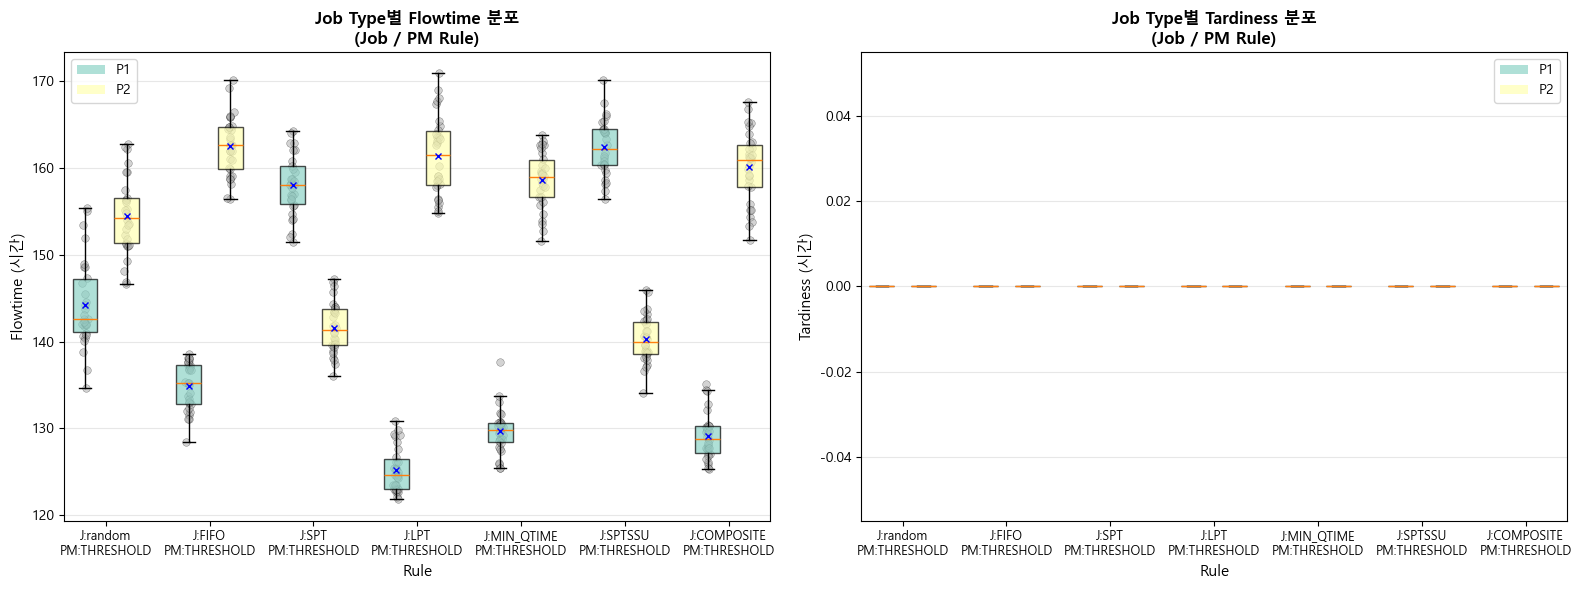

In [11]:
_unit_label = {'M': '분', 'H': '시간', 'D': '일'}.get(os.getenv('TIME_UNIT', 'M'), '분')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rule_indices = [(job_rule, pm_rule) for job_rule in JOB_RULES for pm_rule in PM_RULES]
rule_labels = [f"J:{idx[0]}\nPM:{idx[1]}" for idx in rule_indices]

# Flowtime by Job Type
flowtime_data = []
for idx, row in metrics_df.iterrows():
    for job_type, flowtime_val in row['flowtime'].items():
        flowtime_data.append({
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'flowtime': flowtime_val
        })

flowtime_df = pd.DataFrame(flowtime_data)
job_types = sorted(flowtime_df['job_type'].unique())

for job_type_idx, job_type in enumerate(job_types):
    box_data = []
    for rule_idx in rule_indices:
        data = flowtime_df[
            (flowtime_df['job_rule'] == rule_idx[0]) &
            (flowtime_df['pm_rule'] == rule_idx[1]) &
            (flowtime_df['job_type'] == job_type)
        ]['flowtime'].values
        box_data.append(data if len(data) > 0 else [0])
    
    positions = np.arange(len(rule_indices)) * (len(job_types) + 0.5) + job_type_idx
    bp = axes[0].boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                         showfliers=False)
    
    colors = plt.cm.Set3(range(len(job_types)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[job_type_idx])
        patch.set_alpha(0.7)
    
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            axes[0].scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            axes[0].plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=5)

axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel(f'Flowtime ({_unit_label})', fontsize=11)
axes[0].set_title('Job Type별 Flowtime 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
axes[0].set_xticks(np.arange(len(rule_indices)) * (len(job_types) + 0.5) + (len(job_types) - 1) / 2)
axes[0].set_xticklabels(rule_labels, fontsize=9)
axes[0].legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set3(i), alpha=0.7) for i in range(len(job_types))],
               job_types, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Tardiness by Job Type
tardiness_data = []
for idx, row in metrics_df.iterrows():
    for job_type, tardiness_val in row['tardiness'].items():
        tardiness_data.append({
            'job_rule': row['job_rule'],
            'pm_rule': row['pm_rule'],
            'job_type': job_type,
            'tardiness': tardiness_val
        })

tardiness_df = pd.DataFrame(tardiness_data)
job_types = sorted(tardiness_df['job_type'].unique())

for job_type_idx, job_type in enumerate(job_types):
    box_data = []
    for rule_idx in rule_indices:
        data = tardiness_df[
            (tardiness_df['job_rule'] == rule_idx[0]) &
            (tardiness_df['pm_rule'] == rule_idx[1]) &
            (tardiness_df['job_type'] == job_type)
        ]['tardiness'].values
        box_data.append(data if len(data) > 0 else [0])
    
    positions = np.arange(len(rule_indices)) * (len(job_types) + 0.5) + job_type_idx
    bp = axes[1].boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                         showfliers=False)
    
    colors = plt.cm.Set3(range(len(job_types)))
    for patch in bp['boxes']:
        patch.set_facecolor(colors[job_type_idx])
        patch.set_alpha(0.7)
    
    for i, data in enumerate(box_data):
        if len(data) > 0 and data[0] != 0:
            x_pos = [positions[i]] * len(data)
            x_jittered = [x + np.random.normal(0, 0.03) for x in x_pos]
            axes[1].scatter(x_jittered, data, alpha=0.5, s=30, color='darkgray', edgecolors='black', linewidth=0.3)
            axes[1].plot(positions[i], np.mean(data), marker='x', markersize=5, markeredgewidth=1, color='blue', zorder=5)

axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel(f'Tardiness ({_unit_label})', fontsize=11)
axes[1].set_title('Job Type별 Tardiness 분포\n(Job / PM Rule)', fontsize=12, fontweight='bold')
axes[1].set_xticks(np.arange(len(rule_indices)) * (len(job_types) + 0.5) + (len(job_types) - 1) / 2)
axes[1].set_xticklabels(rule_labels, fontsize=9)
axes[1].legend([plt.Rectangle((0, 0), 1, 1, fc=plt.cm.Set3(i), alpha=0.7) for i in range(len(job_types))],
               job_types, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()